# Python for (open) Neuroscience  
### Practical 2.5 — *Plotting*
#### Module 02 - Scientific Stack

**How to use this notebook**
- Complete the `____` blanks.
- Keep the starter code structure whenever possible.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (8, 5)
sns.set_theme(style='whitegrid')

## Load the data

Use the CSV files if they are in the same folder as this notebook.

In [3]:
subjects = pd.read_csv("data" / Path("subjects.csv"))
trials = pd.read_csv("data" / Path("trials.csv"))
subject_summary = pd.read_csv("data" / Path("subject_summary.csv"))
erp = pd.read_csv("data" / Path("erp_timecourse.csv"))
roi = pd.read_csv("data" / Path("roi_activation.csv"))

subjects.head()


,subject,group,age,sex,handedness,sleep_hours,caffeine_mg,bdi_score,stai_state,notes
0,S01,mci,38,M,right,6.3,159,12,31,elevated memory complaints
1,S02,control,20,F,right,7.9,0,11,41,healthy volunteer
2,S03,mci,33,F,right,6.2,117,8,51,elevated memory complaints
3,S04,control,22,F,right,8.0,69,2,21,healthy volunteer
4,S05,control,24,F,right,7.5,47,11,30,healthy volunteer


## Exercise 1 — Histogram of reaction times

Plot a histogram of trial-level reaction times (`rt_ms`) from `trials`. Add an informative title and axis labels.

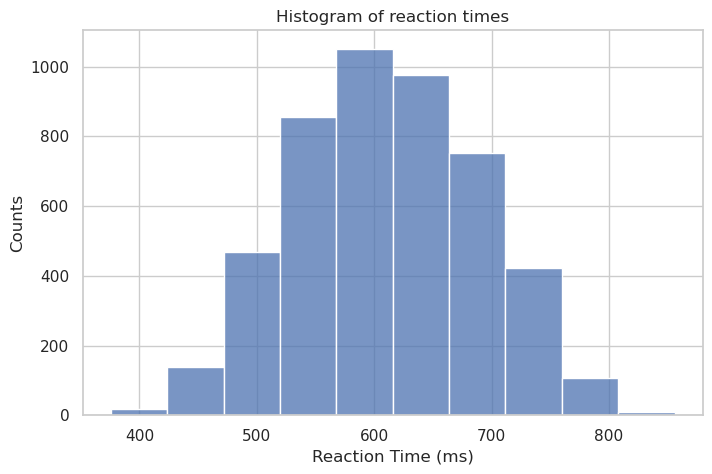

In [4]:
# Your code here
plt.figure()
sns.histplot(data=trials, x="rt_ms", bins=10)
plt.title("Histogram of reaction times")
plt.xlabel(f"Reaction Time (ms)")
plt.ylabel(f"Counts")
plt.show()


## Exercise 2 — Compare RT distributions across conditions

Create a boxplot of `rt_ms` by `group`. Then overlay individual observations with a stripplot using a small alpha.

**New function:** `sns.stripplot()` overlays individual points on top of summary plots such as boxplots.

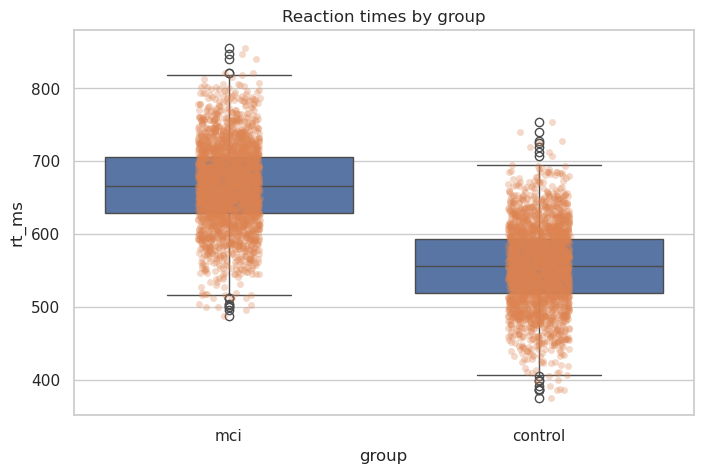

In [5]:
# merge subjects with trials
merged_df = pd.merge(trials, subjects, on="subject")

# Starter code
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x="group", y="rt_ms")
sns.stripplot(data=merged_df, x="group", y="rt_ms", alpha=0.3, jitter=True)
plt.title("Reaction times by group")
plt.show()


## Exercise 3 — Accuracy by group

Use `subject_summary` to create a barplot of mean accuracy by `group`, with error bars.

**New function:** In recent seaborn versions, `errorbar='sd'` or `errorbar=('ci', 95)` controls the uncertainty bars.

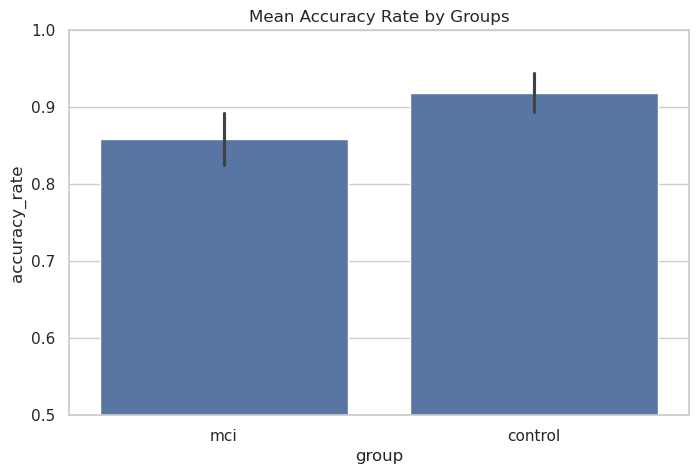

In [6]:
# Hint: accuracy column is `accuracy_rate`
plt.figure()
sns.barplot(data=subject_summary, x="group", y="accuracy_rate", errorbar='sd')
plt.title("Mean Accuracy Rate by Groups")
plt.ylim(0.5, 1)
plt.show()


## Exercise 4 — Scatterplot with regression line

Plot `mean_rt_ms` against `working_memory_score` from `subject_summary`, color points by `group`, and add a regression line.

**New function or concept:** `sns.regplot()` can add a fitted regression line. Here we disable its own scatter points with `scatter=False`.

In [7]:
plt.figure()
sns.scatterplot(data=subject_summary, x="mean_rt_ms", y="working_memory_score", hue="group")
sns.regplot(data=subject_summary, x="mean_rt_ms", y="working_memory_score", scatter=False)
plt.title("Working memory score as a function of mean reaction time")
plt.show()


ValueError: Could not interpret value `working_memory_score` for `y`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

## Exercise 5 — Select and plot only correct trials

Filter `trials` to keep only correct responses, then create a violin plot of `rt_ms` by `condition`.

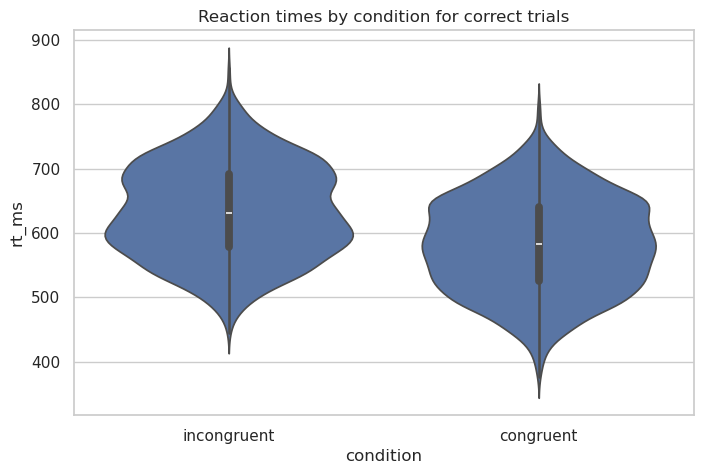

In [8]:
# Step 1: filter
correct_trials = trials[trials["accuracy"] == 1]

# Step 2: plot
plt.figure()
sns.violinplot(data=correct_trials, x="condition", y="rt_ms")
plt.title("Reaction times by condition for correct trials")
plt.show()


## Exercise 6 — Facet plots across groups

Using subject_summary, create separate scatterplots of `accuracy_rate` vs `mean_rt_ms` for each `group` using seaborn's faceting system.

**New function:** `sns.relplot()` is a figure-level function that can create faceted plots across rows or columns.

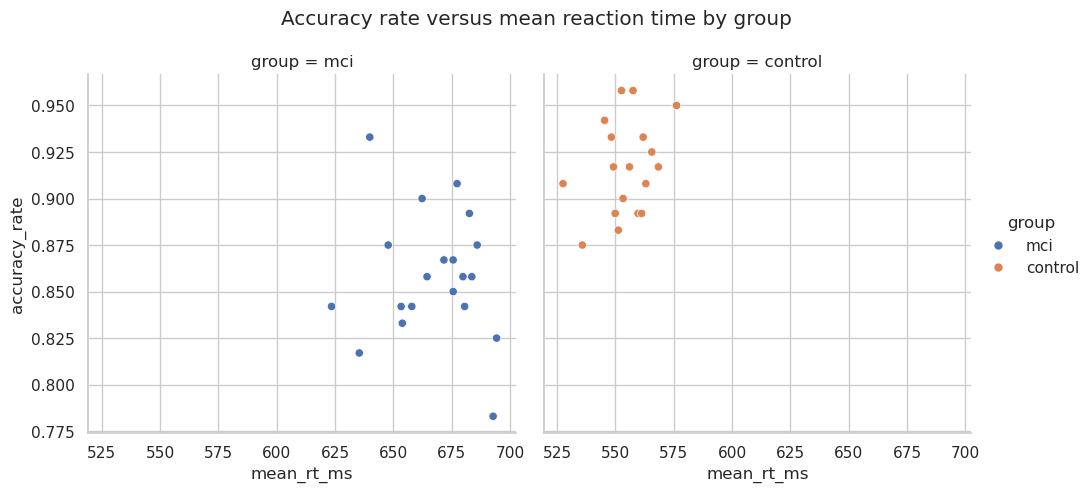

In [10]:
g = sns.relplot(
    data=subject_summary,
    x="mean_rt_ms",
    y="accuracy_rate",
    col="group",
    hue="group",
)
g.fig.suptitle("Accuracy rate versus mean reaction time by group")
g.fig.subplots_adjust(top=0.85)
plt.show()


## Exercise 7 — Grouped summary with pandas then plot

Compute the mean reaction time by `group` and `condition` using pandas, reset the index, then plot the result with seaborn. Use the `merged_df` you created earlier.

**New function:** `reset_index()` converts grouped index levels back into normal columns so seaborn can use them easily.

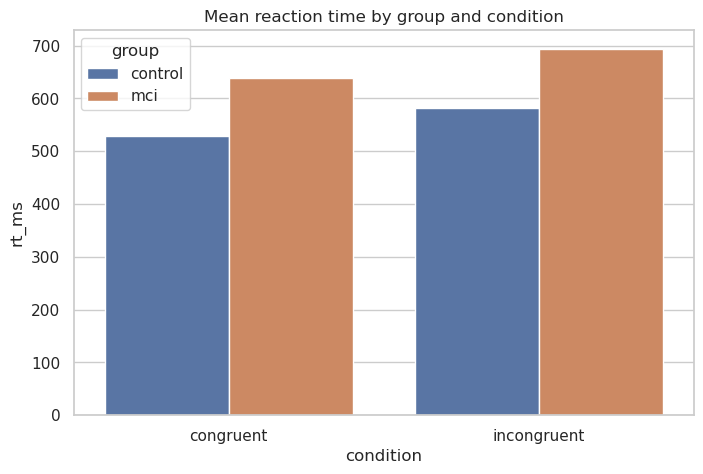

In [12]:
summary = (
    merged_df
    .groupby(["group","condition"])["rt_ms"]
    .mean()
    .reset_index()
)

summary

plt.figure()
sns.barplot(data=summary, x="condition", y="rt_ms", hue="group")
plt.title("Mean reaction time by group and condition")
plt.show()


## Exercise 8 — Time-course plot of ERP waveforms

Plot ERP amplitude over time for each condition using `erp_timecourse`. Use `time_ms` on the x-axis and `amplitude_uv` on the y-axis.

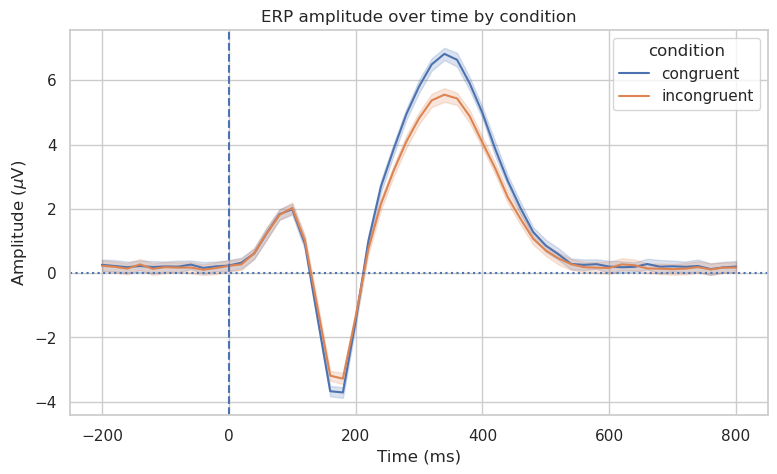

In [13]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=erp, x="time_ms", y="amplitude_uv", hue="condition")
plt.axvline(0, linestyle='--')
plt.axhline(0, linestyle=':')
plt.title("ERP amplitude over time for each condition")
plt.xlabel(f"Time (ms)")
plt.ylabel(f"Amplitude ($\mu$V)")
plt.show()


## Exercise 9 — ERP plot by condition and group

Extend the previous exercise by creating one ERP panel per group.

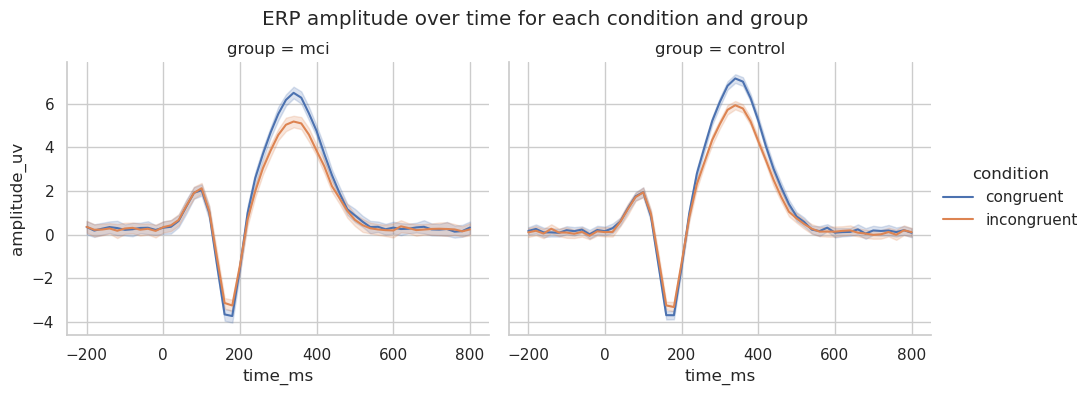

In [15]:
g = sns.relplot(
    data=erp,
    kind="line",
    x="time_ms",
    y="amplitude_uv",
    hue="condition",
    col="group",
    height=4,
    aspect=1.2
)
g.fig.suptitle("ERP amplitude over time for each condition and group")
g.fig.subplots_adjust(top=0.85)
plt.show()


## Exercise 10 — ROI activation heatmap

Pivot the ROI activation table so rows are ROIs, columns are contrasts, and values are `beta_weight`. Then plot a heatmap.

 Use `pivot_table()` to derive the data matrix, which is useful for heatmaps.

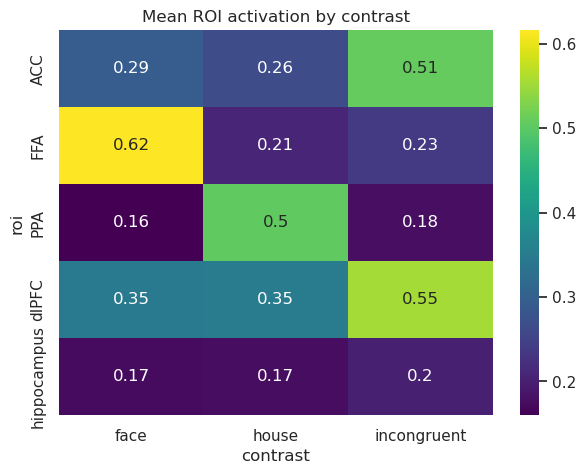

In [17]:
heatmap_data = roi.pivot_table(index="roi", columns="contrast", values="beta_weight", aggfunc = "mean")

heatmap_data

plt.figure(figsize=(7, 5))
sns.heatmap(heatmap_data, annot=True, cmap="viridis")
plt.title("Mean ROI activation by contrast")
plt.show()


## Exercise 11 — Find the slowest participants

Sort `subject_summary` by `mean_rt_ms`, take the 10 slowest participants, and create a horizontal barplot.

**New function:** A horizontal barplot is often clearer when labels or IDs are shown on the y-axis.

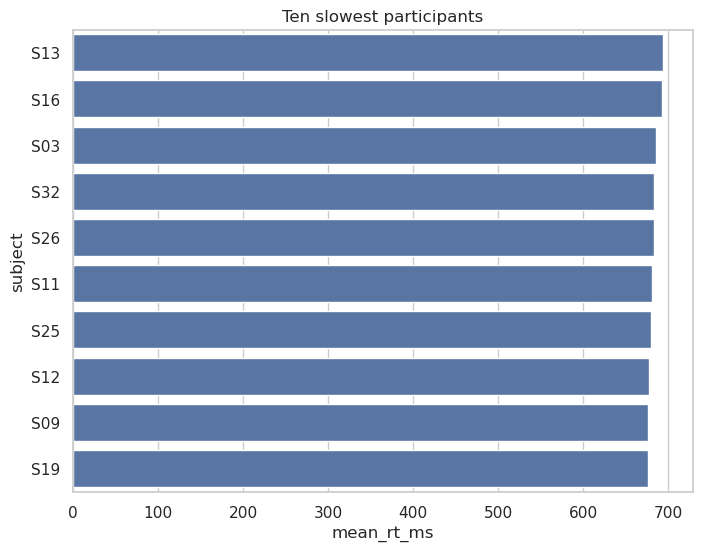

In [20]:
slowest = (
    subject_summary
    .sort_values(by="mean_rt_ms", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 6))
sns.barplot(data=slowest, x="mean_rt_ms", y="subject", orient="h")
plt.title("Ten slowest participants")
plt.show()


## Exercise 12 — Multi-panel figure with matplotlib

Create a 2x2 figure with: histogram of `age`, countplot of `group`, scatterplot of `accuracy_rate` vs `mean_rt_ms`, and boxplot of `pupil_baseline_mm` by `group`.

**New function:** `plt.subplots()` creates a grid of axes so you can build multi-panel figures.

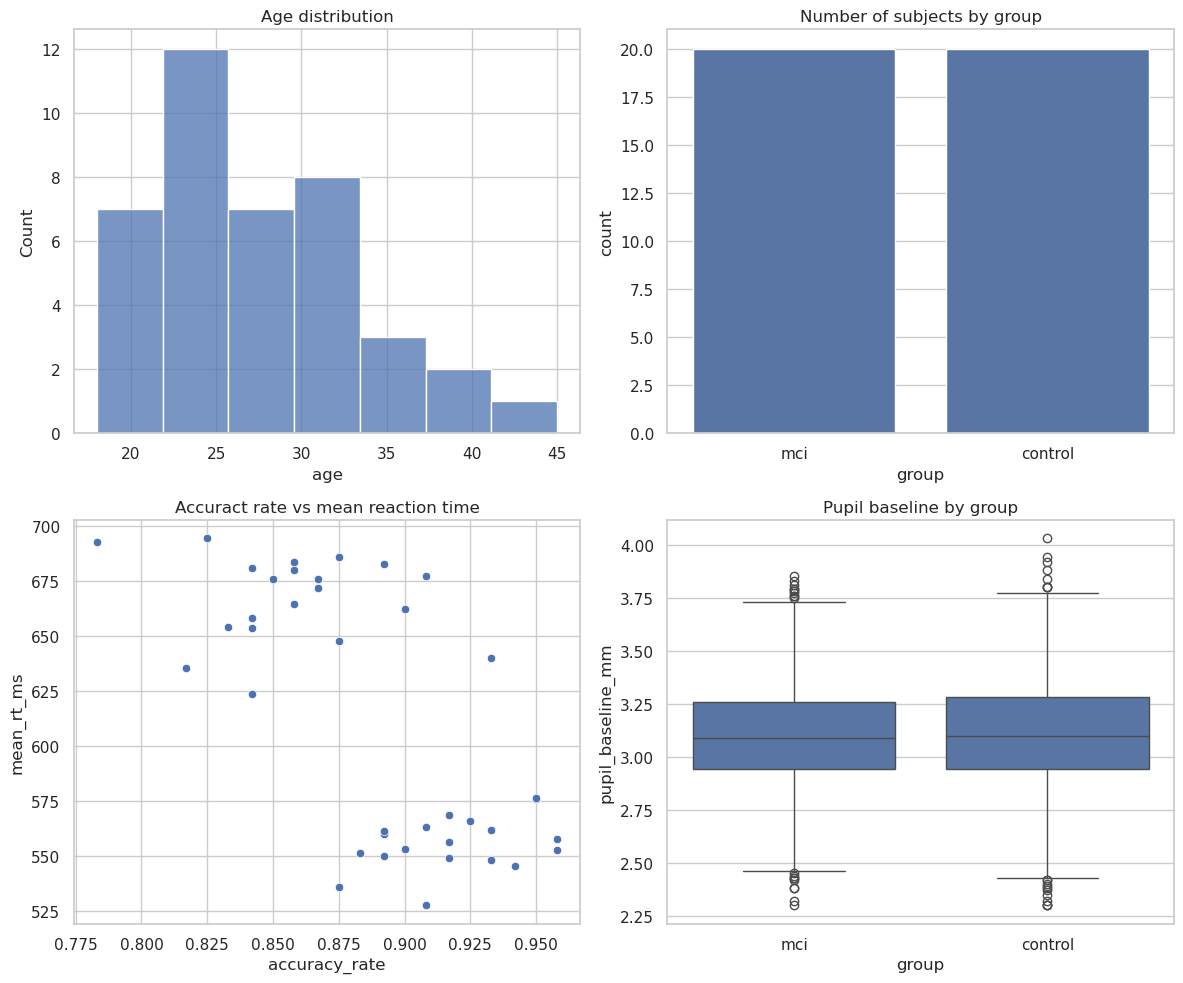

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(data=subject_summary, x="age", ax=axes[0, 0])
sns.countplot(data=subject_summary, x="group", ax=axes[0, 1])
sns.scatterplot(data=subject_summary, x="accuracy_rate", y="mean_rt_ms", ax=axes[1, 0])
sns.boxplot(data=merged_df, x="group", y="pupil_baseline_mm", ax=axes[1, 1])

axes[0, 0].set_title("Age distribution")
axes[0, 1].set_title("Number of subjects by group")
axes[1, 0].set_title("Accuract rate vs mean reaction time")
axes[1, 1].set_title("Pupil baseline by group")

plt.tight_layout()
plt.show()


## Exercise 13 — Correlation heatmap from selected variables

Select a subset of numerical columns from `subject_summary`, compute the correlation matrix, and visualize it.

**New function:** `.corr()` computes pairwise correlations between numerical columns.

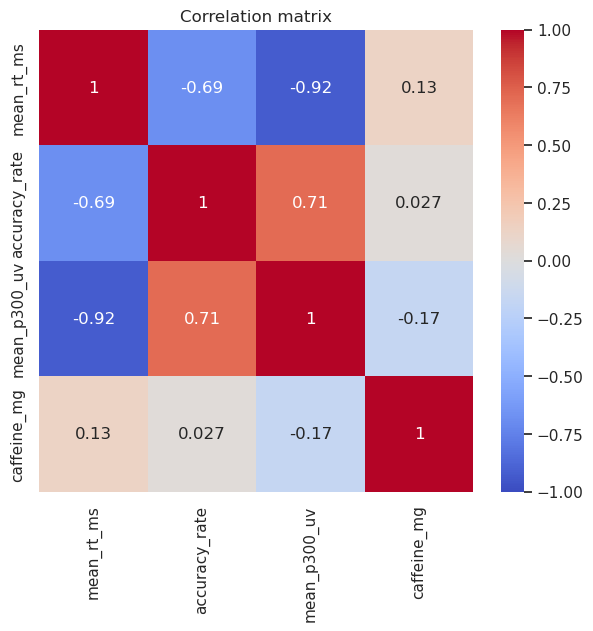

In [24]:
cols = ["mean_rt_ms", "accuracy_rate", "mean_p300_uv", "caffeine_mg"]
corr = subject_summary[cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()


## Exercise 14 — Condition effect within each subject

From `trials`, compute each subject's mean RT separately for each condition, reshape so the conditions are separate columns, and make a scatterplot comparing them.

**New function or concept:** This combines `groupby()` with `pivot()` to move from long format to wide format for subject-wise comparisons.

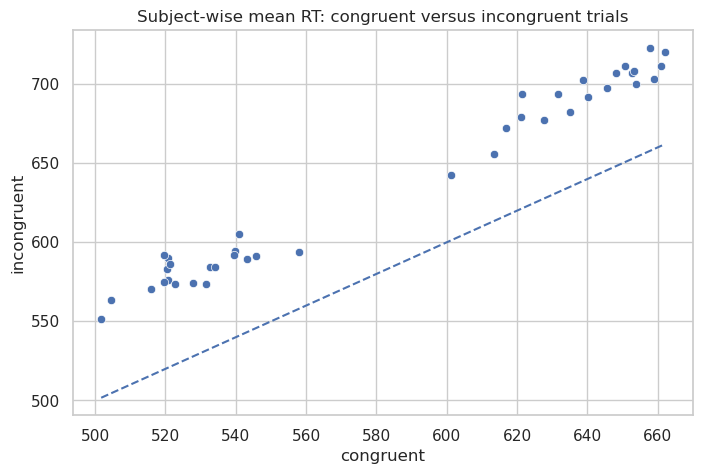

In [25]:
subject_condition = (
    trials
    .groupby(["subject", "condition"])["rt_ms"]
    .mean()
    .reset_index()
)

wide = subject_condition.pivot(index="subject", columns="condition", values="rt_ms")
wide = wide.reset_index()

wide.head()

plt.figure()
sns.scatterplot(data=wide, x="congruent", y="incongruent")
plt.plot([wide.iloc[:,1].min(), wide.iloc[:,1].max()],
         [wide.iloc[:,1].min(), wide.iloc[:,1].max()],
         linestyle='--')
plt.title("Subject-wise mean RT: congruent versus incongruent trials")
plt.show()
